In [1]:
# !pip install torch diffusers transformers accelerate scipy safetensors

### Importing Libraries

In [2]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

### Loading the Model

In [3]:
text2img = StableDiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\jayso\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\jayso\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Setting runtime to GPU

In [4]:
text2img = text2img.to("cuda")

### Generating Images

In [5]:
prompts = ["A futuristic city floating in the sky","A robot studying in library","A beautiful sunset over a cyberpunk city"]


In [6]:
from tqdm import tqdm

images = []
for prompt in tqdm(prompts, desc="Generating images"):
    image = text2img(prompt,
                    negative_prompt="low quality, blurry",
                    num_inference_steps=50,
                    guidance_scale=7.5,
                    generator=torch.Generator("cuda").manual_seed(42)
                ).images[0]
    images.append((prompt,image))

Generating images:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating images:  33%|███▎      | 1/3 [00:06<00:12,  6.44s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating images:  67%|██████▋   | 2/3 [00:11<00:05,  5.75s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating images: 100%|██████████| 3/3 [00:16<00:00,  5.66s/it]


### Rendering the generated images

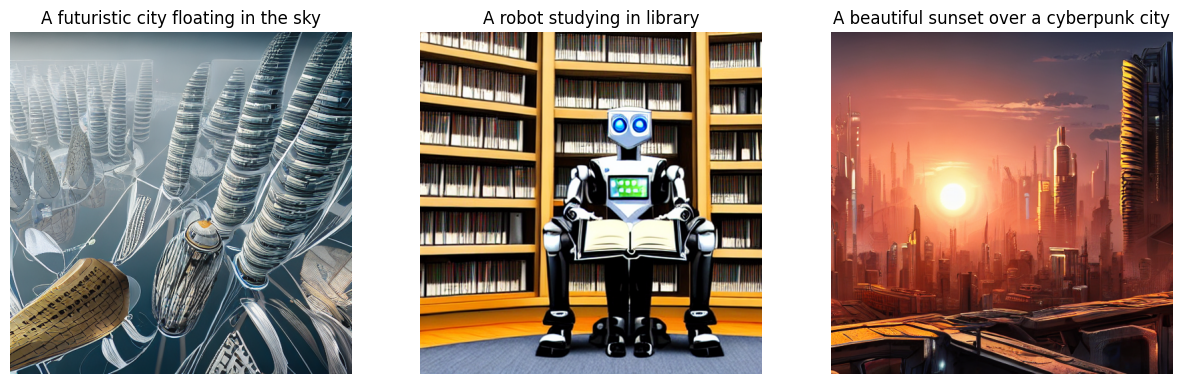

In [7]:
plt.figure(figsize=(15,5))

for i, (prompt, img) in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(img)
    plt.title(prompt)
    plt.axis("off")

plt.show()